In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

data = pd.read_csv("/content/gdrive/MyDrive/ia/KaggleV2-May-2016.csv")
print(data.shape)
data.head()

Mounted at /content/gdrive
(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
data = data.drop(["PatientId", "AppointmentID", "Neighbourhood",
                  "ScheduledDay", "AppointmentDay"], axis=1)

data["Gender"] = data["Gender"].map({"F": 0, "M": 1})
data["No-show"] = data["No-show"].str.strip().map({"No": 0, "Yes": 1})

print(data["No-show"].value_counts())
data.info()

No-show
0    88208
1    22319
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Gender        110527 non-null  int64
 1   Age           110527 non-null  int64
 2   Scholarship   110527 non-null  int64
 3   Hipertension  110527 non-null  int64
 4   Diabetes      110527 non-null  int64
 5   Alcoholism    110527 non-null  int64
 6   Handcap       110527 non-null  int64
 7   SMS_received  110527 non-null  int64
 8   No-show       110527 non-null  int64
dtypes: int64(9)
memory usage: 7.6 MB


In [ ]:
X = data.drop("No-show", axis=1).values
y = data["No-show"].values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110527, 8)
y shape: (110527,)


In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
print("Media:", mu)
print("Desviación estándar:", sigma)

Media: [3.50023071e-01 3.70888742e+01 9.82655822e-02 1.97245922e-01
 7.18647932e-02 3.03998118e-02 2.22479575e-02 3.21025632e-01]
Desviación estándar: [ 0.47697686 23.11010042  0.29767341  0.39791955  0.25826391  0.17168478
  0.161542    0.46687062]


In [ ]:
m = y.size
X_final = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print("X_final shape:", X_final.shape)

X_final shape: (110527, 9)


In [ ]:
def computeCost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    J = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return J

In [ ]:
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        theta = theta - (alpha / m) * (X.T.dot(errors))
        cost_history.append(computeCost(X, y, theta))
    return theta, cost_history

In [ ]:
theta = np.zeros(X_final.shape[1])
alpha = 0.01
iterations = 1000

theta, cost_history = gradientDescent(X_final, y, theta, alpha, iterations)

print("Theta final:", theta)
print("Costo final:", computeCost(X_final, y, theta))

Theta final: [ 0.20192384 -0.00124178 -0.0235288   0.00921082 -0.003861    0.00327913
  0.00359268  0.00084156  0.05111791]
Costo final: 0.07892400422805565


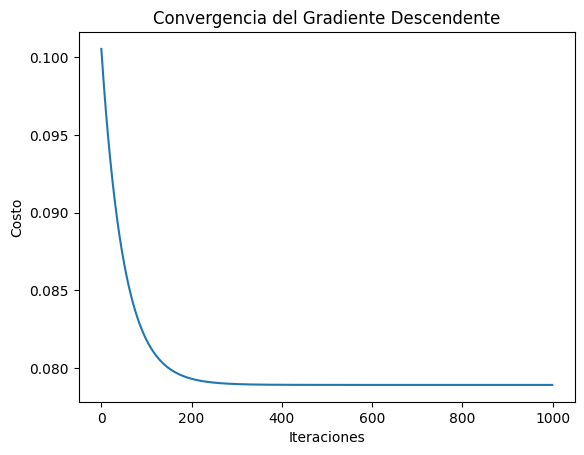

In [ ]:
plt.plot(cost_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia del Gradiente Descendente")
plt.show()

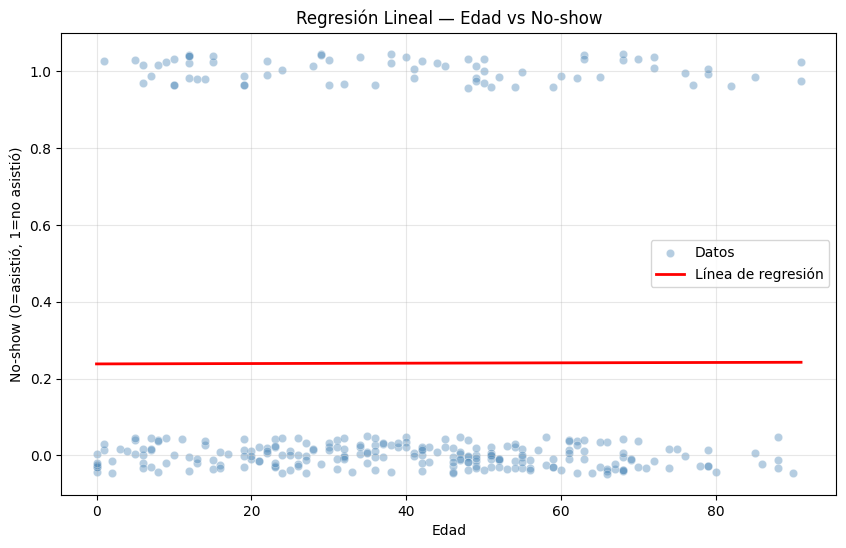

In [ ]:
# Usar solo la columna Age para graficar en 2D
x_plot = data["Age"].values
y_plot = data["No-show"].values

# Tomar muestra aleatoria de 300 puntos para que se vea bien
np.random.seed(42)
indices = np.random.choice(len(x_plot), 300, replace=False)
x_muestra = x_plot[indices]
y_muestra = y_plot[indices]

# Calcular la línea recta: y = m*x + b
m_linea = np.polyfit(x_muestra, y_muestra, 1)
x_linea = np.linspace(x_muestra.min(), x_muestra.max(), 100)
y_linea = m_linea[0] * x_linea + m_linea[1]

# Graficar
plt.figure(figsize=(10, 6))

# Puntos dispersos con ruido para que no se apilen
ruido = np.random.uniform(-0.05, 0.05, size=len(y_muestra))
plt.scatter(x_muestra, y_muestra + ruido, color="steelblue", alpha=0.4,
            edgecolors="white", linewidths=0.5, label="Datos")

# Línea recta de regresión
plt.plot(x_linea, y_linea, color="red", linewidth=2, label="Línea de regresión")

plt.xlabel("Edad")
plt.ylabel("No-show (0=asistió, 1=no asistió)")
plt.title("Regresión Lineal — Edad vs No-show")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()